# Text Representation Techniques
### Count Vectorizer, TF-IDF, and Word2Vec (CBOW & Skip-Gram)


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)


True

## Dataset Preparation & Text Cleaning

In [2]:
corpus = [
    {"id": 1, "category": "technology", "text": "Artificial intelligence and machine learning models are revolutionizing modern computer science and software development."},
    {"id": 2, "category": "technology", "text": "Deep learning neural networks require massive computing power and graphics processing units GPU for training."},
    {"id": 3, "category": "technology", "text": "Natural language processing allows computers to understand, analyze, and generate human languages effectively."},
    {"id": 4, "category": "technology", "text": "Cloud computing providers offer scalable virtual servers, storage databases, and AI machine learning APIs."},
    {"id": 5, "category": "technology", "text": "Python is a popular programming language for data science, artificial intelligence, and web development."},
    {"id": 6, "category": "space", "text": "Astronomers discover new planets and distant galaxies using powerful optical and infrared space telescopes."},
    {"id": 7, "category": "space", "text": "NASA and SpaceX launch rockets and spacecraft into outer space to explore Mars and the Moon."},
    {"id": 8, "category": "space", "text": "The solar system consists of the Sun, eight planets, moons, asteroids, comets, and cosmic dust particles."},
    {"id": 9, "category": "space", "text": "Astronauts aboard the international space station conduct scientific experiments in zero gravity orbit."},
    {"id": 10, "category": "space", "text": "Black holes possess immense gravitational pull such that even light cannot escape their event horizon."},
    {"id": 11, "category": "health", "text": "Regular physical exercise, balanced nutrition, and sufficient sleep promote long term cardiovascular health."},
    {"id": 12, "category": "health", "text": "Medical researchers develop novel vaccines, antibiotics, and therapeutic treatments to fight infectious viral diseases."},
    {"id": 13, "category": "health", "text": "Doctors and healthcare professionals recommend a diet rich in fruits, vegetables, proteins, and essential vitamins."},
    {"id": 14, "category": "health", "text": "Mental health awareness encourages mindfulness meditation, stress reduction techniques, and emotional wellness."},
    {"id": 15, "category": "health", "text": "Hospitals utilize advanced medical diagnostics, magnetic resonance imaging MRI, and genetic sequencing."},
    {"id": 16, "category": "sports", "text": "Football players train rigorously on tactical formations, sprint speed, passing accuracy, and teamwork."},
    {"id": 17, "category": "sports", "text": "The Olympic games bring together global athletes competing in athletics, swimming, gymnastics, and cycling."},
    {"id": 18, "category": "sports", "text": "Basketball teams focus on fast breaks, three point shooting defense, rebounds, and tactical coaching."},
    {"id": 19, "category": "sports", "text": "Tennis champions master powerful serves, baseline forehands, backhand slices, and mental endurance."},
    {"id": 20, "category": "sports", "text": "Marathon runners require intense cardiovascular endurance, proper hydration, and strategic pacing."},
    {"id": 21, "category": "finance", "text": "Stock market investors analyze corporate financial statements, earnings reports, interest rates, and revenue growth."},
    {"id": 22, "category": "finance", "text": "Central banks manage monetary policy, inflation targets, interest rates, and economic stability."},
    {"id": 23, "category": "finance", "text": "Venture capital funds invest capital into early stage technology startups with high growth potential."},
    {"id": 24, "category": "finance", "text": "Cryptocurrency assets, digital tokens, and blockchain ledgers facilitate decentralized financial transactions."},
    {"id": 25, "category": "finance", "text": "Global trade, supply chain logistics, and currency exchange rates affect international business commerce."}
]

df = pd.DataFrame(corpus)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)
df.head(5)


,id,category,text,cleaned_text
0,1,technology,Artificial intelligence and machine learning m...,artificial intelligence machine learning model...
1,2,technology,Deep learning neural networks require massive ...,deep learning neural networks require massive ...
2,3,technology,Natural language processing allows computers t...,natural language processing allows computers u...
3,4,technology,Cloud computing providers offer scalable virtu...,cloud computing providers offer scalable virtu...
4,5,technology,Python is a popular programming language for d...,python popular programming language data scien...


## 1. Count Vectorizer

In [3]:
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(df['cleaned_text'])
features = vectorizer.get_feature_names_out()

print(f"DTM Shape: {dtm.shape}")
print(f"Vocabulary Size: {len(features)}")
print("Sample vocabulary:", features[:15])


DTM Shape: (25, 255)
Vocabulary Size: 255
Sample vocabulary: ['aboard' 'accuracy' 'advanced' 'affect' 'ai' 'allows' 'analyze'
 'antibiotics' 'apis' 'artificial' 'assets' 'asteroids' 'astronauts'
 'astronomers' 'athletes']


In [4]:
dtm_df = pd.DataFrame(dtm.toarray(), columns=features, index=[f"Doc_{i+1}" for i in range(len(df))])

sample_cols = [c for c in ['learning', 'intelligence', 'space', 'planets', 'health', 'exercise', 'rates', 'financial'] if c in features]
dtm_df.iloc[:8][sample_cols]


,learning,intelligence,space,planets,health,exercise,rates,financial
Doc_1,1,1,0,0,0,0,0,0
Doc_2,1,0,0,0,0,0,0,0
Doc_3,0,0,0,0,0,0,0,0
Doc_4,1,0,0,0,0,0,0,0
Doc_5,0,1,0,0,0,0,0,0
Doc_6,0,0,1,1,0,0,0,0
Doc_7,0,0,1,0,0,0,0,0
Doc_8,0,0,0,1,0,0,0,0


In [5]:
for idx in [0, 5, 10]:
    row = dtm_df.iloc[idx]
    active = row[row > 0]
    print(f"Doc {idx+1} ({df.iloc[idx]['category']}):")
    print(df.iloc[idx]['text'])
    print(active.to_dict(), "\n")


Doc 1 (technology):
Artificial intelligence and machine learning models are revolutionizing modern computer science and software development.
{'artificial': 1, 'computer': 1, 'development': 1, 'intelligence': 1, 'learning': 1, 'machine': 1, 'models': 1, 'modern': 1, 'revolutionizing': 1, 'science': 1, 'software': 1} 

Doc 6 (space):
Astronomers discover new planets and distant galaxies using powerful optical and infrared space telescopes.
{'astronomers': 1, 'discover': 1, 'distant': 1, 'galaxies': 1, 'infrared': 1, 'new': 1, 'optical': 1, 'planets': 1, 'powerful': 1, 'space': 1, 'telescopes': 1, 'using': 1} 

Doc 11 (health):
Regular physical exercise, balanced nutrition, and sufficient sleep promote long term cardiovascular health.
{'balanced': 1, 'cardiovascular': 1, 'exercise': 1, 'health': 1, 'long': 1, 'nutrition': 1, 'physical': 1, 'promote': 1, 'regular': 1, 'sleep': 1, 'sufficient': 1, 'term': 1} 



In [6]:
term_freq = pd.DataFrame({
    'word': features,
    'total_count': dtm.toarray().sum(axis=0),
    'doc_count': (dtm.toarray() > 0).sum(axis=0)
}).sort_values(by='total_count', ascending=False).reset_index(drop=True)

print("Top 10 Most Frequent Words:")
display(term_freq.head(10))

query_words = ['learning', 'space', 'health', 'tactical', 'financial', 'planets']
print("\nFrequency of Selected Words:")
display(term_freq[term_freq['word'].isin(query_words)])


Top 10 Most Frequent Words:


,word,total_count,doc_count
0,learning,3,3
1,space,3,3
2,rates,3,3
3,machine,2,2
4,global,2,2
5,tactical,2,2
6,computing,2,2
7,development,2,2
8,science,2,2
9,endurance,2,2



Frequency of Selected Words:


,word,total_count,doc_count
0,learning,3,3
1,space,3,3
5,tactical,2,2
11,financial,2,2
16,health,2,2
17,planets,2,2


In [7]:
sparsity = (1.0 - (dtm.count_nonzero() / (dtm.shape[0] * dtm.shape[1]))) * 100
print(f"Matrix Sparsity: {sparsity:.2f}%")
print("Interpretation:")
print("- Sparse Bag-of-Words representation.")
print("- Words are treated as independent orthogonal dimensions without semantic relationships.")
print("- Word order and syntactic structure are discarded.")


Matrix Sparsity: 95.55%
Interpretation:
- Sparse Bag-of-Words representation.
- Words are treated as independent orthogonal dimensions without semantic relationships.
- Word order and syntactic structure are discarded.


## 2. TF-IDF (Term Frequency - Inverse Document Frequency)

In [8]:
# Manual TF & IDF calculation demonstration on mini-sample
sample_docs = df['cleaned_text'].tolist()[:3]
tokens_list = [d.split() for d in sample_docs]
vocab_sample = sorted(list(set(w for d in tokens_list for w in d)))
n_docs = len(sample_docs)

df_counts = {w: sum(1 for d in tokens_list if w in d) for w in vocab_sample}
idf_values = {w: np.log((1 + n_docs) / (1 + df_counts[w])) + 1 for w in vocab_sample}

print("Sample Calculated IDF (first 5 words):")
for w in vocab_sample[:5]:
    print(f"  {w:15s} | DF: {df_counts[w]}/{n_docs} | IDF: {idf_values[w]:.4f}")


Sample Calculated IDF (first 5 words):
  allows          | DF: 1/3 | IDF: 1.6931
  analyze         | DF: 1/3 | IDF: 1.6931
  artificial      | DF: 1/3 | IDF: 1.6931
  computer        | DF: 1/3 | IDF: 1.6931
  computers       | DF: 1/3 | IDF: 1.6931


In [9]:
tfidf = TfidfVectorizer()
tfidf_mat = tfidf.fit_transform(df['cleaned_text'])
tfidf_features = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_mat.toarray(), columns=tfidf_features, index=[f"Doc_{i+1}" for i in range(len(df))])

idf_df = pd.DataFrame({
    'feature': tfidf_features,
    'idf': tfidf.idf_
}).sort_values(by='idf', ascending=False).reset_index(drop=True)

print("Highest IDF Words (Rarest across corpus):")
display(idf_df.head(5))

print("Lowest IDF Words (Most common across documents):")
display(idf_df.tail(5))


Highest IDF Words (Rarest across corpus):


,feature,idf
0,aboard,3.564949
1,outer,3.564949
2,particles,3.564949
3,passing,3.564949
4,physical,3.564949


Lowest IDF Words (Most common across documents):


,feature,idf
250,development,3.159484
251,computing,3.159484
252,rates,2.871802
253,space,2.871802
254,learning,2.871802


In [10]:
print("Sample Document TF-IDF Scores:")
for idx in [0, 6, 11]:
    scores = tfidf_df.iloc[idx]
    top_words = scores[scores > 0].sort_values(ascending=False).head(4)
    print(f"\nDoc {idx+1} ({df.iloc[idx]['category']}):")
    print(df.iloc[idx]['text'])
    for word, val in top_words.items():
        print(f"  {word:15s}: {val:.4f}")


Sample Document TF-IDF Scores:

Doc 1 (technology):
Artificial intelligence and machine learning models are revolutionizing modern computer science and software development.
  computer       : 0.3231
  models         : 0.3231
  modern         : 0.3231
  revolutionizing: 0.3231

Doc 7 (space):
NASA and SpaceX launch rockets and spacecraft into outer space to explore Mars and the Moon.
  explore        : 0.3219
  launch         : 0.3219
  mars           : 0.3219
  moon           : 0.3219

Doc 12 (health):
Medical researchers develop novel vaccines, antibiotics, and therapeutic treatments to fight infectious viral diseases.
  antibiotics    : 0.2913
  develop        : 0.2913
  diseases       : 0.2913
  fight          : 0.2913


In [11]:
doc1_terms = [t for t in tfidf_features if tfidf_df.loc['Doc_1', t] > 0]
comparison = pd.DataFrame({
    'term': doc1_terms,
    'count': [dtm_df.loc['Doc_1', t] for t in doc1_terms],
    'idf': [idf_df[idf_df['feature'] == t]['idf'].values[0] for t in doc1_terms],
    'tfidf': [tfidf_df.loc['Doc_1', t] for t in doc1_terms]
}).sort_values(by='tfidf', ascending=False).reset_index(drop=True)

print("Count Vectorizer vs TF-IDF on Doc 1:")
display(comparison)


Count Vectorizer vs TF-IDF on Doc 1:


,term,count,idf,tfidf
0,computer,1,3.564949,0.323149
1,models,1,3.564949,0.323149
2,modern,1,3.564949,0.323149
3,revolutionizing,1,3.564949,0.323149
4,software,1,3.564949,0.323149
5,artificial,1,3.159484,0.286395
6,development,1,3.159484,0.286395
7,intelligence,1,3.159484,0.286395
8,machine,1,3.159484,0.286395
9,science,1,3.159484,0.286395


In [12]:
print("Interpretation:")
print("- TF-IDF reduces weight of common words across documents (low IDF) and boosts rare domain-specific words.")
print("- Normalized by L2 norm, making document vectors comparable regardless of text length.")


Interpretation:
- TF-IDF reduces weight of common words across documents (low IDF) and boosts rare domain-specific words.
- Normalized by L2 norm, making document vectors comparable regardless of text length.


## 3. Word2Vec (CBOW & Skip-Gram)

In [13]:
tokenized_sentences = [text.split() for text in df['cleaned_text'].tolist()]

cbow = Word2Vec(sentences=tokenized_sentences, vector_size=50, window=4, min_count=1, sg=0, epochs=200, seed=42)
skipgram = Word2Vec(sentences=tokenized_sentences, vector_size=50, window=4, min_count=1, sg=1, epochs=200, seed=42)

print(f"CBOW Vocab Size: {len(cbow.wv)}")
print(f"Skip-Gram Vocab Size: {len(skipgram.wv)}")


CBOW Vocab Size: 255
Skip-Gram Vocab Size: 255


In [14]:
sample_words = ['intelligence', 'space', 'planets', 'health', 'athletes', 'financial']
print("Dense Vector Representations (first 6 dims):")
for w in sample_words:
    vec = skipgram.wv[w]
    print(f"{w:15s} (dim={len(vec)}): {np.round(vec[:6], 3)}...")


Dense Vector Representations (first 6 dims):
intelligence    (dim=50): [ 0.117 -0.531  0.453  0.188  0.138 -0.07 ]...
space           (dim=50): [ 0.104 -0.483  0.041 -0.082  0.263 -0.685]...
planets         (dim=50): [-0.157 -0.434  0.115 -0.104  0.248 -0.09 ]...
health          (dim=50): [-0.022  0.111  0.006 -0.083  0.303  0.019]...
athletes        (dim=50): [-0.206 -0.37   0.152  0.285 -0.188  0.207]...
financial       (dim=50): [-0.004 -0.032 -0.524 -0.125  0.044 -0.527]...


In [15]:
print("Most Similar Words (Cosine Similarity):")
for w in ['intelligence', 'space', 'health']:
    sims = skipgram.wv.most_similar(w, topn=3)
    print(f"{w:12s} -> {[(item[0], round(item[1], 3)) for item in sims]}")


Most Similar Words (Cosine Similarity):


intelligence -> [('artificial', 0.994), ('development', 0.991), ('science', 0.99)]
space        -> [('moon', 0.874), ('astronauts', 0.872), ('aboard', 0.87)]
health       -> [('awareness', 0.939), ('encourages', 0.928), ('mindfulness', 0.917)]


In [16]:
pairs = [
    ('intelligence', 'learning'),
    ('space', 'planets'),
    ('exercise', 'health'),
    ('space', 'football'),
    ('vaccines', 'basketball')
]

pair_rows = []
for w1, w2 in pairs:
    pair_rows.append({
        'Word 1': w1,
        'Word 2': w2,
        'CBOW Cosine Sim': round(float(cbow.wv.similarity(w1, w2)), 4),
        'Skip-Gram Cosine Sim': round(float(skipgram.wv.similarity(w1, w2)), 4)
    })

display(pd.DataFrame(pair_rows))


,Word 1,Word 2,CBOW Cosine Sim,Skip-Gram Cosine Sim
0,intelligence,learning,0.9962,0.8102
1,space,planets,0.9948,0.5351
2,exercise,health,0.9939,0.7961
3,space,football,0.9917,0.3495
4,vaccines,basketball,0.9909,0.5041


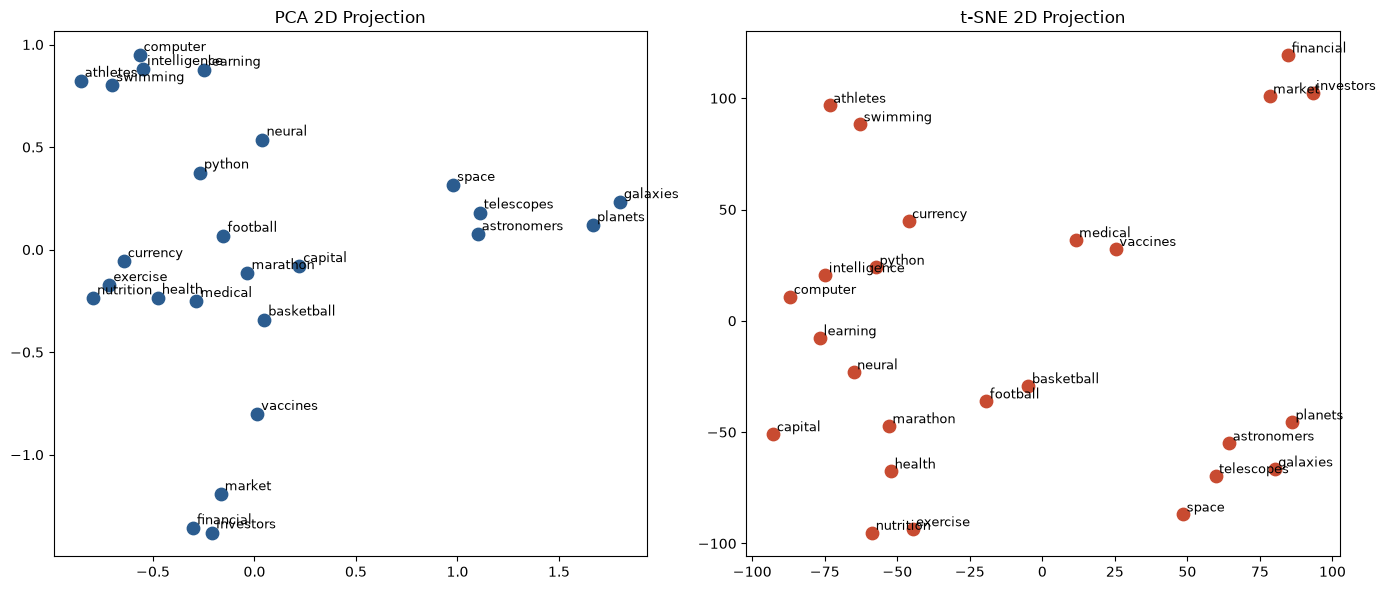

In [17]:
plot_words = [
    'intelligence', 'learning', 'neural', 'computer', 'python',
    'space', 'planets', 'astronomers', 'galaxies', 'telescopes',
    'health', 'exercise', 'nutrition', 'vaccines', 'medical',
    'athletes', 'football', 'basketball', 'swimming', 'marathon',
    'financial', 'market', 'investors', 'capital', 'currency'
]
vocab = [w for w in plot_words if w in skipgram.wv]
vectors = np.array([skipgram.wv[w] for w in vocab])

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(vectors)

tsne = TSNE(n_components=2, random_state=42, perplexity=4, init='pca', learning_rate='auto')
tsne_2d = tsne.fit_transform(vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(pca_2d[:, 0], pca_2d[:, 1], color='#2b5c8f', s=80)
for i, txt in enumerate(vocab):
    ax1.annotate(txt, (pca_2d[i, 0] + 0.02, pca_2d[i, 1] + 0.02), fontsize=9)
ax1.set_title("PCA 2D Projection")

ax2.scatter(tsne_2d[:, 0], tsne_2d[:, 1], color='#c84b31', s=80)
for i, txt in enumerate(vocab):
    ax2.annotate(txt, (tsne_2d[i, 0] + 1.2, tsne_2d[i, 1] + 1.2), fontsize=9)
ax2.set_title("t-SNE 2D Projection")

plt.tight_layout()
plt.show()
